In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

In [4]:
df = pd.read_csv('Truck_sales.csv')
raw_data = df.iloc[:, 1].values.reshape(-1, 1)

In [5]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(raw_data)

In [6]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [7]:
X, y = create_sequences(data_scaled, 12)
train_size = int(len(X) * 0.8)

In [8]:
X_train = torch.FloatTensor(X[:train_size])
y_train = torch.FloatTensor(y[:train_size])
X_test = torch.FloatTensor(X[train_size:])
y_test = torch.FloatTensor(y[train_size:])

In [9]:
def plot_result(y_true, y_pred, name, mse, color):
    plt.figure(figsize=(10, 4))
    true_vals = scaler.inverse_transform(y_true.numpy())
    pred_vals = scaler.inverse_transform(y_pred.detach().numpy())

    plt.plot(true_vals, label='Реальность', color='black')
    plt.plot(pred_vals, label=f'Предсказание {name}', color=color, linestyle='--')
    plt.title(f"{name} | MSE: {mse:.6f}")
    plt.legend()
    plt.show()

In [10]:
#RNN
class ManualRNN(nn.Module):
    def __init__(self, h_size=32):
        super().__init__()
        self.h_size = h_size
        self.w_x = nn.Parameter(torch.randn(1, h_size) * 0.1)
        self.w_h = nn.Parameter(torch.randn(h_size, h_size) * 0.1)
        self.w_out = nn.Parameter(torch.randn(h_size, 1) * 0.1)

    def forward(self, x):
        h = torch.zeros(x.size(0), self.h_size)
        for t in range(x.size(1)):
            h = torch.tanh(x[:, t, :] @ self.w_x + h @ self.w_h)
        return h @ self.w_out

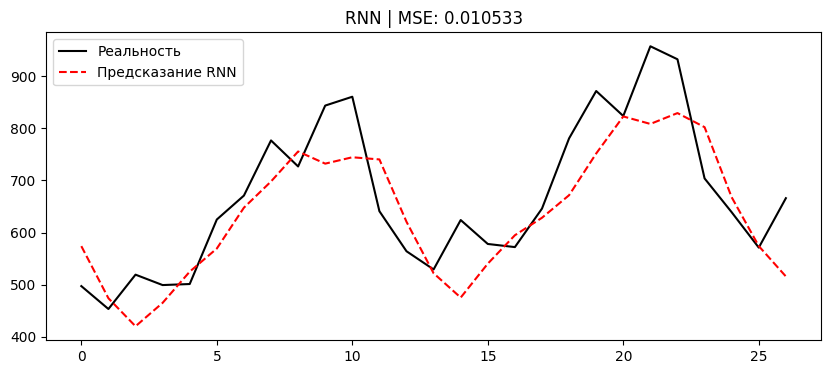

In [11]:
model_rnn = ManualRNN()
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(100):
    preds = model_rnn(X_train)
    loss = criterion(preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
plot_result(y_test, model_rnn(X_test), "RNN", criterion(model_rnn(X_test), y_test).item(), "red")

In [12]:
class ManualGRU(nn.Module):
    def __init__(self, h_size=32):
        super().__init__()
        self.h_size = h_size
        self.w_gate = nn.Parameter(torch.randn(1 + h_size, h_size) * 0.1)
        self.w_data = nn.Parameter(torch.randn(1 + h_size, h_size) * 0.1)
        self.w_out = nn.Parameter(torch.randn(h_size, 1) * 0.1)

    def forward(self, x):
        h = torch.zeros(x.size(0), self.h_size)
        for t in range(x.size(1)):
            combined = torch.cat((x[:, t, :], h), dim=1)
            gate = torch.sigmoid(combined @ self.w_gate)
            info = torch.tanh(combined @ self.w_data)
            h = gate * h + (1 - gate) * info
        return h @ self.w_out

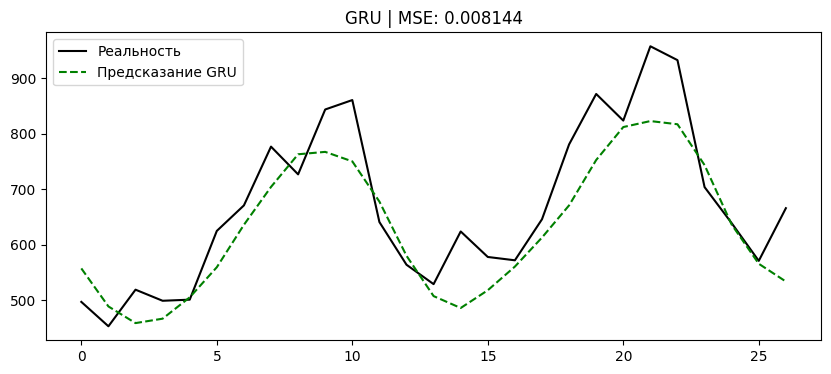

In [13]:
model_gru = ManualGRU()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=0.01)

for epoch in range(100):
    loss = criterion(model_gru(X_train), y_train)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
plot_result(y_test, model_gru(X_test), "GRU", criterion(model_gru(X_test), y_test).item(), "green")